# Projet Morel : Scoring pour Service Solution Client

# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
import gc
import joblib
import mlflow
import mlflow.sklearn

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from datetime import datetime


c:\Users\15GIRAV\Moi\Boulot\OpenClassrooms\P8_Confirmez_vos_competences_en_MLOPS_partie_2_2\.venv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# MLflow — configuration

In [2]:
# Backend SQLite local pour le tracking
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Une seule expérience pour TOUT le projet (benchmark + optimisation),
# afin de pouvoir comparer tous les runs entre eux dans l'UI MLflow.
EXPERIMENT_NAME = "Projet_Morel_Scoring_BERA_M"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ Configuration MLflow initialisée (expérience : '{EXPERIMENT_NAME}').")


✅ Configuration MLflow initialisée (expérience : 'Projet_Morel_Scoring_BERA_M').


# Récupération de la table de données nettoyée

In [3]:
df_final_model_enriched = pd.read_csv('df_final_model_enriched.csv')
df_final_model_enriched.head()

,Unnamed: 0,Famille_1_N_signature_2,Famille_3_N_signature_4,Famille_10_N_signature_1,is_BERA_M,Famille_5_N_signature_1,Famille_6_N_signature_1,Turnover_N_signature_2,Famille_9_N_signature_2,Famille_13_N_signature_1,...,customer_value_score,branche,clp_contrat_ap_stat,annees_depuis_1ere_facture,annees_depuis_dernier_achat,code_departemental,pot_40_calc,GrandCompte,NOTE_COFACE,EC
0,0,30.0,22.0,22.0,1,0.0,0.0,7023.759766,2.0,0.0,...,69.0,4903.0,BK,21.0,0.0,22.0,18421.0,True,6.0,87.7
1,1,4.0,51.0,3.0,1,3.0,0.0,7214.049805,3.0,0.0,...,96.0,4078.0,BK,21.0,0.0,82.0,18421.0,True,4.0,9.2
2,2,113.0,2.0,51.0,1,0.0,0.0,12811.910156,10.0,0.0,...,88.0,5237.0,BK,21.0,0.0,22.0,7875.0,True,7.0,6.3
3,3,0.0,0.0,14.0,1,25.0,0.0,5540.299805,3.0,0.0,...,80.0,3001.0,AE,21.0,0.0,24.0,7143.0,True,3.0,47.9
4,4,11.0,0.0,6.0,1,0.0,0.0,2259.689941,6.0,11.0,...,47.0,3003.0,NaN,21.0,0.0,83.0,5357.0,True,9.0,0.0


In [4]:
df_final_model_enriched=df_final_model_enriched.drop(columns=['Unnamed: 0'])
df_final_model_enriched.head()

,Famille_1_N_signature_2,Famille_3_N_signature_4,Famille_10_N_signature_1,is_BERA_M,Famille_5_N_signature_1,Famille_6_N_signature_1,Turnover_N_signature_2,Famille_9_N_signature_2,Famille_13_N_signature_1,Famille_1_N_signature_4,...,customer_value_score,branche,clp_contrat_ap_stat,annees_depuis_1ere_facture,annees_depuis_dernier_achat,code_departemental,pot_40_calc,GrandCompte,NOTE_COFACE,EC
0,30.0,22.0,22.0,1,0.0,0.0,7023.759766,2.0,0.0,14.0,...,69.0,4903.0,BK,21.0,0.0,22.0,18421.0,True,6.0,87.7
1,4.0,51.0,3.0,1,3.0,0.0,7214.049805,3.0,0.0,3.0,...,96.0,4078.0,BK,21.0,0.0,82.0,18421.0,True,4.0,9.2
2,113.0,2.0,51.0,1,0.0,0.0,12811.910156,10.0,0.0,58.0,...,88.0,5237.0,BK,21.0,0.0,22.0,7875.0,True,7.0,6.3
3,0.0,0.0,14.0,1,25.0,0.0,5540.299805,3.0,0.0,0.0,...,80.0,3001.0,AE,21.0,0.0,24.0,7143.0,True,3.0,47.9
4,11.0,0.0,6.0,1,0.0,0.0,2259.689941,6.0,11.0,0.0,...,47.0,3003.0,NaN,21.0,0.0,83.0,5357.0,True,9.0,0.0


In [5]:
df_final_model_enriched["division"]

0         15-001
1         15-001
2         15-000
3         15-011
4         15-011
           ...  
182057    53-999
182058    53-999
182059    53-999
182060    53-999
182061    53-999
Name: division, Length: 182062, dtype: str

In [6]:
df_final_model_enriched.info()


<class 'pandas.DataFrame'>
RangeIndex: 182062 entries, 0 to 182061
Data columns (total 87 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Famille_1_N_signature_2      182062 non-null  float64
 1   Famille_3_N_signature_4      182062 non-null  float64
 2   Famille_10_N_signature_1     182062 non-null  float64
 3   is_BERA_M                    182062 non-null  int64  
 4   Famille_5_N_signature_1      182062 non-null  float64
 5   Famille_6_N_signature_1      182062 non-null  float64
 6   Turnover_N_signature_2       182062 non-null  float64
 7   Famille_9_N_signature_2      182062 non-null  float64
 8   Famille_13_N_signature_1     182062 non-null  float64
 9   Famille_1_N_signature_4      182062 non-null  float64
 10  Famille_2_N_signature_3      182062 non-null  float64
 11  Famille_16_N_signature_2     182062 non-null  float64
 12  Famille_10_N_signature_4     182062 non-null  float64
 13  Nb_lignes_

# Préparation du dataset

On exclut uniquement les colonnes réellement présentes dans le CSV qui ne doivent pas
servir de features : identifiants, cible, et `NOTE_COFACE` (score externe volontairement
mis de côté de l'entraînement, mais réintégré plus tard dans le livrable commercial).


In [7]:
# ==========================================================
# IDENTIFICATION DES FEATURES DE MODÉLISATION
# ==========================================================
colonnes_a_exclure = ["code_client", "compagny", "is_BERA_M", "NOTE_COFACE"]
features_model = [col for col in df_final_model_enriched.columns if col not in colonnes_a_exclure]

X = df_final_model_enriched[features_model].copy()
y = df_final_model_enriched["is_BERA_M"].astype(int)

# ✅ DÉTECTION ROBUSTE - Couvre object + string[python] + category
import pandas as pd
from pandas.api.types import is_string_dtype, is_categorical_dtype

colonnes_cat = [
    col for col in X.columns 
    if X[col].dtype == 'object' 
    or is_string_dtype(X[col]) 
    or is_categorical_dtype(X[col])
]

print(f"✅ Colonnes catégorielles détectées : {colonnes_cat}")
print(f"   Leurs dtypes: {[str(X[col].dtype) for col in colonnes_cat]}")

# IMPORTANT: Force le dtype category pour la stabilité
for col in colonnes_cat:
    X[col] = X[col].astype('category')

✅ Colonnes catégorielles détectées : ['division', 'clp_contrat_ap_stat']
   Leurs dtypes: ['str', 'str']


C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_22172\3588025512.py:18: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or is_categorical_dtype(X[col])


In [8]:
# ==========================================================
# SPLIT TRAIN / TEST — fait une seule fois, réutilisé partout
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nStructure de l'entraînement (X_train) : {X_train.shape}")
print(f"Structure du test (X_test) : {X_test.shape}")


Structure de l'entraînement (X_train) : (145649, 83)
Structure du test (X_test) : (36413, 83)


# Benchmark de 3 modèles (XGBoost / Random Forest / LightGBM)

Grilles volontairement légères ici : l'objectif est de **comparer les familles de modèles**,
pas encore d'optimiser finement. `X_test` n'est utilisé qu'à titre indicatif à ce stade —
la décision finale d'hyperparamètres pour le modèle retenu se fera uniquement sur la CV
interne au train, dans la section d'optimisation approfondie plus bas.


In [9]:
def build_xgb_pipeline():
    return Pipeline([
        ("encoder", TargetEncoder(
            cols=colonnes_cat,  
            handle_missing="value",
            handle_unknown="value",
            smoothing=10.0
        )),
        ("imputer", SimpleImputer(strategy='median')),
        ("smote", SMOTE(random_state=42)),
        ("xgb", XGBClassifier(random_state=42, n_jobs=1, eval_metric="logloss")),
    ])

def build_rf_pipeline():
    return Pipeline([
        ("encoder", TargetEncoder(cols=colonnes_cat, handle_missing="value", handle_unknown="value", smoothing=10.0)),
        ("imputer", SimpleImputer(strategy='median')),
        ("smote", SMOTE(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42, n_jobs=1, class_weight="balanced")),
    ])

def build_lgb_pipeline():
    return Pipeline([
        ("encoder", TargetEncoder(cols=colonnes_cat, handle_missing="value", handle_unknown="value", smoothing=10.0)),
        ("imputer", SimpleImputer(strategy='median')),
        ("smote", SMOTE(random_state=42)),
        ("lgb", LGBMClassifier(random_state=42, n_jobs=1, class_weight="balanced", verbose=-1)),
    ])

resultats_benchmark = {}

In [10]:
param_dist_xgb = {
    "smote__sampling_strategy": [0.25, 0.5, "auto"],
    "xgb__n_estimators": [100, 150, 200],
    "xgb__max_depth": [3, 4, 5, 6],
    "xgb__learning_rate": [0.05, 0.1, 0.2],
}

random_search_xgb = RandomizedSearchCV(
    estimator=build_xgb_pipeline(),
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=2,
    verbose=1,
)

print("\n🚀 Benchmark XGBoost...")
with mlflow.start_run(run_name="Benchmark_XGBoost"):
    random_search_xgb.fit(X_train, y_train)  # ✅ Ça va marcher !
    best_xgb_benchmark = random_search_xgb.best_estimator_

    for param_name, param_value in random_search_xgb.best_params_.items():
        mlflow.log_param(param_name, param_value)

    y_score_xgb = best_xgb_benchmark.predict_proba(X_test)[:, 1]
    auc_xgb = roc_auc_score(y_test, y_score_xgb)
    mlflow.log_metric("auc_test", auc_xgb)

resultats_benchmark["XGBoost"] = auc_xgb
print(f"✅ AUC test XGBoost (benchmark) : {auc_xgb:.4f}")


🚀 Benchmark XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ AUC test XGBoost (benchmark) : 0.9879


In [11]:
# ---------------- Random Forest (benchmark) ----------------
param_dist_rf = {
    "smote__sampling_strategy": ["auto"],
    "rf__n_estimators": [50, 100],
    "rf__max_depth": [5, 10],
}

random_search_rf = RandomizedSearchCV(
    estimator=build_rf_pipeline(),
    param_distributions=param_dist_rf,
    n_iter=3, scoring="roc_auc", cv=3, random_state=42, n_jobs=-1, verbose=1,
)

print("🚀 Benchmark Random Forest...")
with mlflow.start_run(run_name="Benchmark_RandomForest"):
    random_search_rf.fit(X_train, y_train)
    best_rf_benchmark = random_search_rf.best_estimator_

    for param_name, param_value in random_search_rf.best_params_.items():
        mlflow.log_param(param_name, param_value)

    y_score_rf = best_rf_benchmark.predict_proba(X_test)[:, 1]
    auc_rf = roc_auc_score(y_test, y_score_rf)
    mlflow.log_metric("auc_test", auc_rf)

resultats_benchmark["RandomForest"] = auc_rf
print(f"✅ AUC test Random Forest (benchmark) : {auc_rf:.4f}")


🚀 Benchmark Random Forest...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
✅ AUC test Random Forest (benchmark) : 0.9821


In [12]:
# ---------------- LightGBM (benchmark) ----------------
param_dist_lgb = {
    "smote__sampling_strategy": [0.25, 0.5, "auto"],
    "lgb__n_estimators": [100, 150, 200],
    "lgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "lgb__num_leaves": [15, 31, 63, 127],
    "lgb__max_depth": [-1, 3, 5, 7, 10],
    "lgb__subsample": [0.7, 0.8, 0.9, 1.0],
}

random_search_lgb = RandomizedSearchCV(
    estimator=build_lgb_pipeline(),
    param_distributions=param_dist_lgb,
    n_iter=10, scoring="roc_auc", cv=5, random_state=42, n_jobs=2, verbose=1,
)

print("🚀 Benchmark LightGBM...")
with mlflow.start_run(run_name="Benchmark_LightGBM"):
    random_search_lgb.fit(X_train, y_train)
    best_lgb_benchmark = random_search_lgb.best_estimator_

    for param_name, param_value in random_search_lgb.best_params_.items():
        mlflow.log_param(param_name, param_value)

    y_score_lgb = best_lgb_benchmark.predict_proba(X_test)[:, 1]
    auc_lgb = roc_auc_score(y_test, y_score_lgb)
    mlflow.log_metric("auc_test", auc_lgb)

resultats_benchmark["LightGBM"] = auc_lgb
print(f"✅ AUC test LightGBM (benchmark) : {auc_lgb:.4f}")


🚀 Benchmark LightGBM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ AUC test LightGBM (benchmark) : 0.9882


## Comparaison explicite des 3 modèles

In [13]:
df_comparaison = (
    pd.Series(resultats_benchmark, name="AUC_test")
    .sort_values(ascending=False)
    .to_frame()
)
print(df_comparaison)

modele_retenu = df_comparaison.index[0]
print(f"\n🏆 Modèle avec la meilleure AUC sur ce premier passage : {modele_retenu}")
print("Pour des raisons d'efficacité du modèle, on poursuit avec XGBoost pour l'optimisation approfondie ci-dessous ")


              AUC_test
LightGBM      0.988190
XGBoost       0.987948
RandomForest  0.982097

🏆 Modèle avec la meilleure AUC sur ce premier passage : LightGBM
Pour des raisons d'efficacité du modèle, on poursuit avec XGBoost pour l'optimisation approfondie ci-dessous 


# Optimisation approfondie de XGBoost

On réutilise le **même pipeline** que pour le benchmark (pas de reconstruction redondante
avec un `ColumnTransformer` séparé).

`X_test` n'est utilisé qu'ici, une seule fois, pour évaluer le modèle final retenu.


In [14]:
param_dist_xgb_final = {
    "smote__sampling_strategy": [0.25, 0.5, "auto"],
    "xgb__n_estimators": [100, 150, 200, 300],
    "xgb__max_depth": [3, 4, 5, 6, 8],
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "xgb__subsample": [0.7, 0.8, 1.0],
    "xgb__colsample_bytree": [0.7, 0.8, 1.0],
}

cv_stratifie = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb_final = RandomizedSearchCV(
    estimator=build_xgb_pipeline(),
    param_distributions=param_dist_xgb_final,
    n_iter=25,
    scoring="roc_auc",
    cv=cv_stratifie,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)


In [15]:
os.makedirs("../models", exist_ok=True)

print("🚀 Recherche approfondie XGBoost + sauvegarde MLflow & locale...")

with mlflow.start_run(run_name="XGBoost_Final_Optimise") as run:

    # ------------------------------------------------------------
    # 1. Entraînement
    # ------------------------------------------------------------
    random_search_xgb_final.fit(X_train, y_train)
    best_pipeline = random_search_xgb_final.best_estimator_

    print("\n--- MEILLEURS PARAMÈTRES TROUVÉS ---")
    print(random_search_xgb_final.best_params_)

    for param_name, param_value in random_search_xgb_final.best_params_.items():
        mlflow.log_param(param_name, param_value)

    # ------------------------------------------------------------
    # 2. Évaluation sur le jeu de test (utilisé une seule fois ici)
    # ------------------------------------------------------------
    y_score = best_pipeline.predict_proba(X_test)[:, 1]
    auc_test_final = roc_auc_score(y_test, y_score)
    mlflow.log_metric("auc_test", auc_test_final)
    print(f"\n✅ AUC test (modèle final) : {auc_test_final:.4f}")

    # ------------------------------------------------------------
    # 3. Optimisation du seuil de décision selon le coût métier
    #    (un faux négatif coûte ~75x plus qu'un faux positif)
    # ------------------------------------------------------------
    cout_appel_inutile = 20     # Temps passé par Nicolas/Manu pour un appel inutile (FP)
    gain_contrat_rate = 1500    # Manque à gagner par client manqué (FN)

    seuils_testes = np.arange(0.05, 0.96, 0.01)
    couts = []
    for seuil in seuils_testes:
        y_pred_s = (y_score >= seuil).astype(int)
        cm_s = confusion_matrix(y_test, y_pred_s)
        fp_s = cm_s[0, 1]
        fn_s = cm_s[1, 0]
        cout = fp_s * cout_appel_inutile + fn_s * gain_contrat_rate
        couts.append(cout)

    couts = np.array(couts)
    meilleur_seuil = seuils_testes[np.argmin(couts)]
    cout_min = couts.min()

    print(f"🎯 Seuil optimal (coût métier minimal) : {meilleur_seuil:.2f}")
    print(f"💰 Coût estimé à ce seuil : {cout_min:.0f} €")

    mlflow.log_param("seuil_decision_optimal", float(meilleur_seuil))
    mlflow.log_metric("cout_total_erreurs_euros", float(cout_min))

    y_pred = (y_score >= meilleur_seuil).astype(int)

    print("\n--- RAPPORT DE CLASSIFICATION (seuil optimisé) ---")
    print(classification_report(y_test, y_pred))

    # ------------------------------------------------------------
    # 4. Sauvegarde du modèle — DANS le run actif (correctif clé)
    # ------------------------------------------------------------
    mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="pipeline_model",
        serialization_format="cloudpickle",
        registered_model_name="XGBoost_BERA_Pipeline",
    )

    joblib.dump(best_pipeline, "../models/best_pipeline_xgboost.pkl")
    print("💾 Modèle également sauvegardé localement sous : '../models/best_pipeline_xgboost.pkl'")

    # Prédictions du jeu de test
    df_pred_final = pd.DataFrame({
        'True_Label': y_test.values,
        'Predicted_Label': y_pred,
        'Probability_Class_1': y_score,
    })
    file_predictions = "predictions_final_model.csv"
    df_pred_final.to_csv(file_predictions, index=False)
    mlflow.log_artifact(file_predictions, artifact_path="predictions")
    os.remove(file_predictions)

    run_id_final = run.info.run_id

print(f"\n✅ Run MLflow final : {run_id_final}")


🚀 Recherche approfondie XGBoost + sauvegarde MLflow & locale...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

--- MEILLEURS PARAMÈTRES TROUVÉS ---
{'xgb__subsample': 0.7, 'xgb__n_estimators': 100, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 0.8, 'smote__sampling_strategy': 0.5}

✅ AUC test (modèle final) : 0.9871
🎯 Seuil optimal (coût métier minimal) : 0.08
💰 Coût estimé à ce seuil : 44000 €

--- RAPPORT DE CLASSIFICATION (seuil optimisé) ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     36167
           1       0.47      0.89      0.61       246

    accuracy                           0.99     36413
   macro avg       0.73      0.94      0.81     36413
weighted avg       1.00      0.99      0.99     36413



2026/09/10 16:21:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/10 16:21:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


💾 Modèle également sauvegardé localement sous : '../models/best_pipeline_xgboost.pkl'

✅ Run MLflow final : 29e1755e21c847d19a4ac8f430eb8adf


Registered model 'XGBoost_BERA_Pipeline' already exists. Creating a new version of this model...
Created version '3' of model 'XGBoost_BERA_Pipeline'.


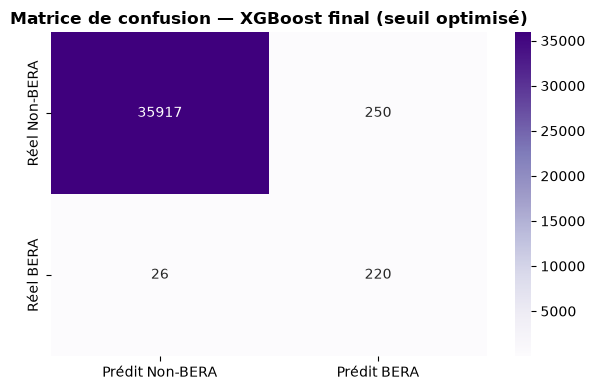

In [16]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Purples", xticklabels=["Prédit Non-BERA", "Prédit BERA"], yticklabels=["Réel Non-BERA", "Réel BERA"])

plt.title("Matrice de confusion — XGBoost final (seuil optimisé)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


# Scoring des prospects

On applique le pipeline final aux clients qui n'ont pas encore l'offre (`is_BERA_M == 0`),
avec le **même seuil optimisé** que celui retenu ci-dessus pour définir les priorités d'appel.


In [17]:
# ==========================================================
# 1. ISOLATION DES PROSPECTS HORS CONTRAT
# ==========================================================
print("🎯 Isolation de la population cible (prospects non-signataires)...")

df_prospects = df_final_model_enriched[df_final_model_enriched["is_BERA_M"] == 0].copy()
X_prospects = df_prospects[features_model].copy()

for col in colonnes_cat:
    X_prospects[col] = X_prospects[col].astype('category')

# ==========================================================
# 2. CALCUL DES SCORES D'APPÉTENCE
# ==========================================================
print("🔮 Calcul des probabilités d'achat (scoring)...")
df_prospects["Score_Appetence_BERA_M"] = best_pipeline.predict_proba(X_prospects)[:, 1]

# ==========================================================
# 3. SEGMENTATION DES PRIORITÉS D'APPEL
#    Bornes calées sur le seuil optimal métier trouvé plus haut,
#    plutôt que des bornes arbitraires (0.75 / 0.40).
# ==========================================================
seuil_bas = meilleur_seuil * 0.6
seuil_haut = meilleur_seuil * 1.3

def assigner_priorite(score):
    if score >= seuil_haut:
        return "1 - TOP PRIORITÉ"
    elif score >= seuil_bas:
        return "2 - PRIORITÉ MOYENNE"
    else:
        return "3 - BASSE PRIORITÉ"

df_prospects["Priorite_Appel"] = df_prospects["Score_Appetence_BERA_M"].apply(assigner_priorite)


🎯 Isolation de la population cible (prospects non-signataires)...
🔮 Calcul des probabilités d'achat (scoring)...


# Vérification de la sauvegarde locale

Petit test de bout en bout : on recharge le `.pkl` et on vérifie qu'il prédit correctement,
pour confirmer que la sauvegarde n'est pas corrompue.


In [18]:
pipeline_recharge = joblib.load("../models/best_pipeline_xgboost.pkl")
score_verif = pipeline_recharge.predict_proba(X_test)[:, 1]

assert np.allclose(score_verif, y_score), "⚠️ Le modèle rechargé ne donne pas les mêmes prédictions !"
print("✅ Le modèle rechargé depuis '../models/best_pipeline_xgboost.pkl' est cohérent avec le modèle entraîné.")


✅ Le modèle rechargé depuis '../models/best_pipeline_xgboost.pkl' est cohérent avec le modèle entraîné.
